# Guía Práctica: Detección y Tratamiento de Datos Duplicados en Pandas

En este notebook aprenderás a identificar, analizar y tratar datos duplicados en tus DataFrames de pandas.

## 1. Importar Librerías
Importamos pandas para el manejo de datos.

In [1]:
import pandas as pd
print("Pandas version:", pd.__version__)


Pandas version: 2.2.3


## 2. Crear un DataFrame con Datos Duplicados
Generamos un DataFrame de ejemplo con filas duplicadas para practicar.

In [2]:
datos = {
    'nombre': ['Ana', 'Luis', 'Ana', 'Pedro', 'Luis', 'Ana'],
    'edad': [23, 30, 23, 40, 30, 23],
    'ciudad': ['Madrid', 'Sevilla', 'Madrid', 'Valencia', 'Sevilla', 'Madrid']
}
df = pd.DataFrame(datos)
print("DataFrame original:")
print(df)

DataFrame original:
  nombre  edad    ciudad
0    Ana    23    Madrid
1   Luis    30   Sevilla
2    Ana    23    Madrid
3  Pedro    40  Valencia
4   Luis    30   Sevilla
5    Ana    23    Madrid


## 3. Identificar Filas Duplicadas
Detectamos qué filas están duplicadas en el DataFrame.

In [3]:
duplicados = df.duplicated()
print("Filas duplicadas (True = duplicado):")
print(duplicados)

Filas duplicadas (True = duplicado):
0    False
1    False
2     True
3    False
4     True
5     True
dtype: bool


## 4. Visualizar Solo las Filas Duplicadas
Mostramos únicamente las filas que son duplicadas.

In [4]:
print("Solo filas duplicadas:")
print(df[df.duplicated()])

Solo filas duplicadas:
  nombre  edad   ciudad
2    Ana    23   Madrid
4   Luis    30  Sevilla
5    Ana    23   Madrid


## 5. Eliminar Filas Duplicadas
Eliminamos los duplicados y mostramos el DataFrame resultante.

In [5]:
df_sin_duplicados = df.drop_duplicates()
print("DataFrame sin duplicados:")
print(df_sin_duplicados)

DataFrame sin duplicados:
  nombre  edad    ciudad
0    Ana    23    Madrid
1   Luis    30   Sevilla
3  Pedro    40  Valencia


## 6. Eliminar Duplicados por una Columna
Podemos eliminar duplicados considerando solo una columna, por ejemplo 'nombre'.

In [6]:
df_sin_duplicados_nombre = df.drop_duplicates(subset=['nombre'])
print("DataFrame sin duplicados por nombre:")
print(df_sin_duplicados_nombre)

DataFrame sin duplicados por nombre:
  nombre  edad    ciudad
0    Ana    23    Madrid
1   Luis    30   Sevilla
3  Pedro    40  Valencia


## 7. Contar y Analizar Duplicados
Podemos contar cuántos duplicados hay y analizar su impacto.

In [7]:
num_duplicados = df.duplicated().sum()
print(f'Cantidad de filas duplicadas: {num_duplicados}')
print(f'Porcentaje de duplicados: {num_duplicados/len(df)*100:.2f}%')

Cantidad de filas duplicadas: 3
Porcentaje de duplicados: 50.00%


## 8. Buenas Prácticas y Consejos
- Siempre revisa los duplicados antes de eliminarlos.
- Puedes usar `keep='first'` o `keep='last'` para controlar qué fila conservar.
- Considera el contexto: a veces los duplicados son válidos.
- Analiza el impacto de eliminar duplicados en tu análisis.

## 9. Visualización de Duplicados

Podemos visualizar los duplicados en el DataFrame para entender mejor su distribución y características.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_5604\1235982549.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=visual_df, x='duplicado', palette='Set2')


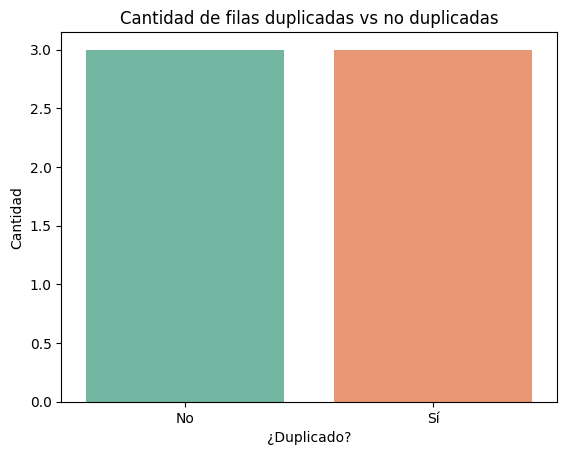

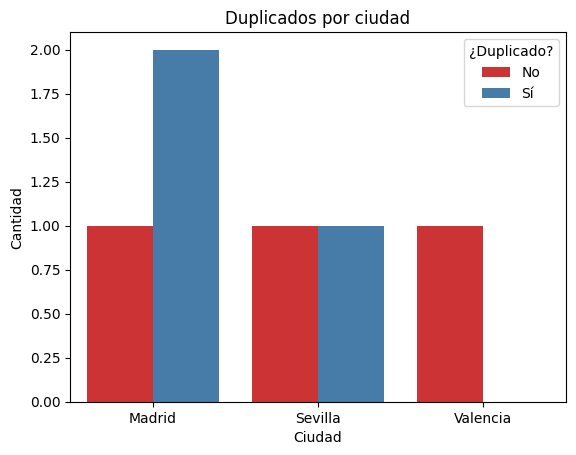

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar una columna que indique si la fila es duplicada
visual_df = df.copy()
visual_df['duplicado'] = visual_df.duplicated()

# Visualización: cantidad de duplicados vs no duplicados
sns.countplot(data=visual_df, x='duplicado', palette='Set2')
plt.title('Cantidad de filas duplicadas vs no duplicadas')
plt.xlabel('¿Duplicado?')
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['No', 'Sí'])
plt.show()

# Visualización: duplicados por ciudad
sns.countplot(data=visual_df, x='ciudad', hue='duplicado', palette='Set1')
plt.title('Duplicados por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Cantidad')
plt.legend(title='¿Duplicado?', labels=['No', 'Sí'])
plt.show()